In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")

sup_latent_df = pd.read_parquet(
    DATA_LATENT / "supervised_cnn_vae_latents.parquet"
)

returns.index = pd.to_datetime(returns.index)
features.index = pd.to_datetime(features.index)
sup_latent_df["date"] = pd.to_datetime(sup_latent_df["date"])

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

sup_latent_df.head()

,date,ticker,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.038254,0.017117,-0.165311,1.134504,-1.445229,1.191268,0.838135,1.248731,-0.626914,-0.358154
1,2015-09-22,AAPL,-0.017760,0.017041,-0.240465,1.112205,-1.361434,1.288137,0.763379,1.212089,-0.619133,-0.295517
2,2015-09-23,AAPL,-0.030634,0.016867,-0.232379,1.105707,-1.205404,1.429420,0.567163,1.272981,-0.573612,-0.353675
3,2015-09-24,AAPL,-0.048136,0.016492,-0.165983,1.043628,-1.174774,1.460648,0.689822,1.340265,-0.535046,-0.214705
4,2015-09-25,AAPL,-0.021688,0.015912,-0.153574,1.114064,-1.045284,1.551994,0.410720,1.297225,-0.525672,-0.213376


In [3]:
HORIZON = 10
REBALANCE_EVERY = 10
TRAIN_RATIO = 0.7

LONG_Q = 0.8
SHORT_Q = 0.2

TRANSACTION_COST = 0.0

In [4]:
def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [5]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [6]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    dates = score_df.index
    tickers = score_df.columns

    positions = pd.DataFrame(
        0.0,
        index=dates,
        columns=tickers
    )

    current_position = pd.Series(0.0, index=tickers)

    for i, date in enumerate(dates):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=tickers)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [7]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    costs = transaction_cost * turnover

    net = gross - costs

    return net, turnover

In [8]:
common_dates = np.sort(sup_latent_df["date"].unique())
split_date = common_dates[int(TRAIN_RATIO * len(common_dates))]

split_date

np.datetime64('2022-03-09T00:00:00.000000000')

In [9]:
direct_score_df = sup_latent_df.pivot(
    index="date",
    columns="ticker",
    values="pred_return_10d"
).sort_index()

direct_score_test = direct_score_df.loc[
    direct_score_df.index >= split_date
]

In [10]:
direct_positions = build_rebalanced_positions_from_scores(
    direct_score_test,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

direct_returns, direct_turnover = portfolio_returns_from_positions(
    direct_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

direct_returns.name = "supervised_vae_direct"

In [11]:
z_cols = [c for c in sup_latent_df.columns if c.startswith("z_")]

train_mask = sup_latent_df["date"] < split_date
test_mask = sup_latent_df["date"] >= split_date

X_train = sup_latent_df.loc[train_mask, z_cols].values
y_train = sup_latent_df.loc[train_mask, "target_return_10d"].values

X_test = sup_latent_df.loc[test_mask, z_cols].values
y_test = sup_latent_df.loc[test_mask, "target_return_10d"].values

sup_z_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

sup_z_model.fit(X_train, y_train)

pred_train = sup_z_model.predict(X_train)
pred_test = sup_z_model.predict(X_test)

print("Supervised z Ridge train corr:", np.corrcoef(y_train, pred_train)[0, 1])
print("Supervised z Ridge test corr:", np.corrcoef(y_test, pred_test)[0, 1])
print("Supervised z Ridge test MSE:", mean_squared_error(y_test, pred_test))

Supervised z Ridge train corr: 0.1457911815060772
Supervised z Ridge test corr: 0.05284797483205069
Supervised z Ridge test MSE: 0.00446833111345768


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [12]:
sup_latent_df["ridge_score"] = sup_z_model.predict(
    sup_latent_df[z_cols].values
)

sup_z_score_df = sup_latent_df.pivot(
    index="date",
    columns="ticker",
    values="ridge_score"
).sort_index()

sup_z_score_test = sup_z_score_df.loc[
    sup_z_score_df.index >= split_date
]

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [13]:
sup_z_positions = build_rebalanced_positions_from_scores(
    sup_z_score_test,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

sup_z_returns, sup_z_turnover = portfolio_returns_from_positions(
    sup_z_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

sup_z_returns.name = "supervised_vae_z_ridge"

In [14]:
future_returns = make_future_returns(returns, HORIZON)

feature_names = features.columns.get_level_values("feature").unique().tolist()
tickers = features.columns.get_level_values("ticker").unique().tolist()

raw_rows = []

for ticker in tickers:
    df_t = features[ticker].copy()
    df_t["target_return"] = future_returns[ticker]
    df_t["date"] = df_t.index
    df_t["ticker"] = ticker
    raw_rows.append(df_t)

raw_work = pd.concat(raw_rows, axis=0).dropna().copy()

In [15]:
raw_train_mask = raw_work["date"] < split_date
raw_test_mask = raw_work["date"] >= split_date

X_train_raw = raw_work.loc[raw_train_mask, feature_names].values
y_train_raw = raw_work.loc[raw_train_mask, "target_return"].values

X_test_raw = raw_work.loc[raw_test_mask, feature_names].values
y_test_raw = raw_work.loc[raw_test_mask, "target_return"].values

raw_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

raw_model.fit(X_train_raw, y_train_raw)

raw_train_pred = raw_model.predict(X_train_raw)
raw_test_pred = raw_model.predict(X_test_raw)

print("Raw Ridge train corr:", np.corrcoef(y_train_raw, raw_train_pred)[0, 1])
print("Raw Ridge test corr:", np.corrcoef(y_test_raw, raw_test_pred)[0, 1])
print("Raw Ridge test MSE:", mean_squared_error(y_test_raw, raw_test_pred))

Raw Ridge train corr: 0.14829928508020834
Raw Ridge test corr: 0.04067034529571518
Raw Ridge test MSE: 0.004475629884269938


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [16]:
raw_work["score"] = raw_model.predict(raw_work[feature_names].values)

raw_score_df = raw_work.pivot(
    index="date",
    columns="ticker",
    values="score"
).sort_index()

raw_score_test = raw_score_df.loc[
    raw_score_df.index >= split_date
]

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [17]:
raw_positions = build_rebalanced_positions_from_scores(
    raw_score_test,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

raw_returns, raw_turnover = portfolio_returns_from_positions(
    raw_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

raw_returns.name = "raw_feature_ridge"

In [18]:
comparison_returns = pd.concat(
    [
        raw_returns,
        direct_returns,
        sup_z_returns,
    ],
    axis=1
).dropna()

stats = comparison_returns.apply(performance_stats).T

stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
supervised_vae_z_ridge,0.191398,0.065268,0.068259,0.956176,-0.087056
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181


In [19]:
turnover_stats = pd.Series({
    "raw_avg_turnover": raw_turnover.mean(),
    "supervised_vae_direct_turnover": direct_turnover.mean(),
    "supervised_vae_z_ridge_turnover": sup_z_turnover.mean(),
})

turnover_stats

raw_avg_turnover                   0.022063
supervised_vae_direct_turnover     0.031423
supervised_vae_z_ridge_turnover    0.016905
dtype: float64

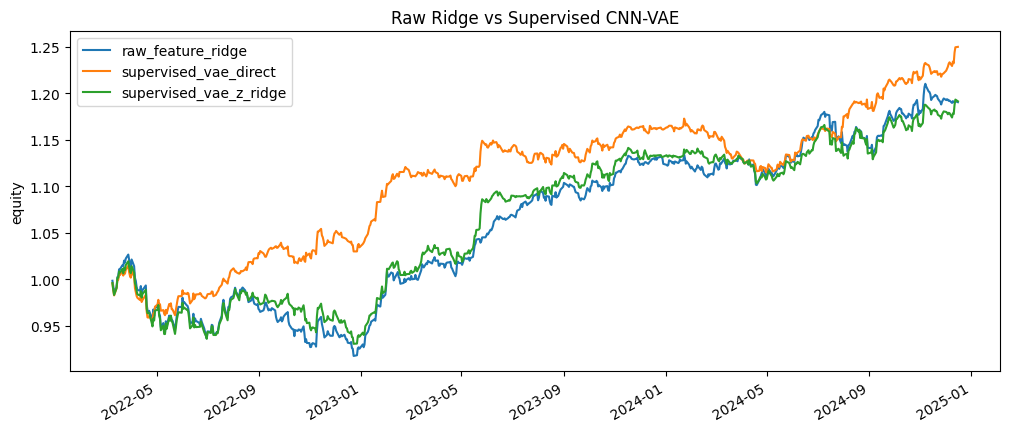

In [20]:
equity = (1 + comparison_returns).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Raw Ridge vs Supervised CNN-VAE"
)

plt.ylabel("equity")
plt.show()

In [21]:
comparison_returns.to_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "supervised_vae_backtest_stats.csv"
)

In [22]:
stats.sort_values("sharpe", ascending=False)
turnover_stats

raw_avg_turnover                   0.022063
supervised_vae_direct_turnover     0.031423
supervised_vae_z_ridge_turnover    0.016905
dtype: float64

In [23]:
stats.sort_values("sharpe", ascending=False)


,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
supervised_vae_z_ridge,0.191398,0.065268,0.068259,0.956176,-0.087056
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181


In [24]:
cost_grid = [
    0.0,
    0.0001,
    0.0005,
    0.0010,
    0.0020,
]

cost_results = []

for tcost in cost_grid:

    raw_r, _ = portfolio_returns_from_positions(
        raw_positions,
        returns,
        transaction_cost=tcost
    )

    direct_r, _ = portfolio_returns_from_positions(
        direct_positions,
        returns,
        transaction_cost=tcost
    )

    supz_r, _ = portfolio_returns_from_positions(
        sup_z_positions,
        returns,
        transaction_cost=tcost
    )

    row = {
        "transaction_cost": tcost,

        "raw_sharpe":
            performance_stats(raw_r)["sharpe"],

        "direct_sharpe":
            performance_stats(direct_r)["sharpe"],

        "supz_sharpe":
            performance_stats(supz_r)["sharpe"],

        "raw_return":
            performance_stats(raw_r)["total_return"],

        "direct_return":
            performance_stats(direct_r)["total_return"],

        "supz_return":
            performance_stats(supz_r)["total_return"],
    }

    cost_results.append(row)

cost_results_df = pd.DataFrame(cost_results)

cost_results_df

,transaction_cost,raw_sharpe,direct_sharpe,supz_sharpe,raw_return,direct_return,supz_return
0,0.0000,0.947015,1.567479,0.956176,0.190417,0.249903,0.191398
1,0.0001,0.938418,1.551640,0.949525,0.188586,0.247166,0.189993
2,0.0005,0.904045,1.488233,0.922933,0.181290,0.236279,0.184390
3,0.0010,0.861117,1.408896,0.889720,0.172232,0.222802,0.177423
4,0.0020,0.775418,1.250157,0.823404,0.154320,0.196280,0.163610


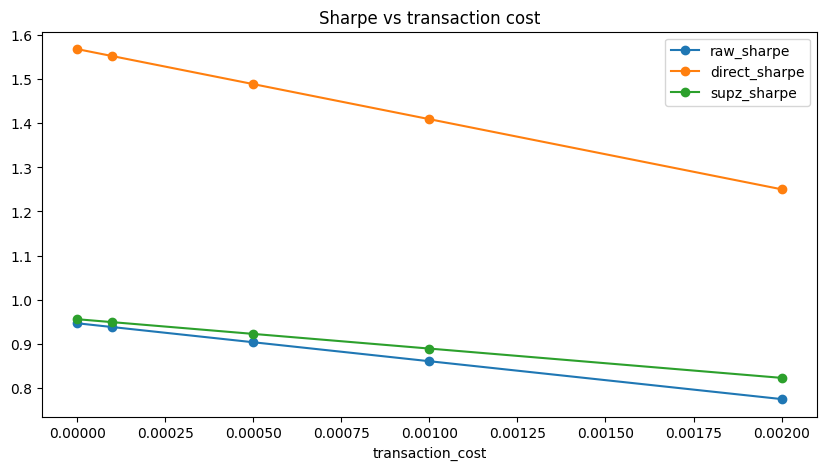

In [25]:
cost_results_df.plot(
    x="transaction_cost",
    y=["raw_sharpe",
       "direct_sharpe",
       "supz_sharpe"],
    marker="o",
    figsize=(10,5)
)

plt.title("Sharpe vs transaction cost")
plt.show()